In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

df = pd.read_csv("../data/tanzania.csv")

df["Country"] = "Tanzania"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


### Data Loading & Preparation

- Tanzania dataset was loaded successfully.
- Country column was added.
- Date column was created from YEAR and DOY.
- Month column extracted for seasonal analysis.

In [78]:
df.replace(-999, np.nan, inplace=True)

missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Value Analysis

- -999 values were replaced with NaN.
- Missing values were checked across all columns.
- The dataset shows minimal missing values.

In [79]:
df.duplicated().sum()

np.int64(0)

### Duplicate Check

- No duplicate rows were found.
- Data integrity is maintained.

In [80]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


### Summary Statistics Interpretation

- Tanzania has a warm tropical climate.
- Rainfall is relatively high compared to drier regions.
- Humidity is high, indicating moist atmospheric conditions.
- Temperature remains stable across the year.

In [81]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(stats.zscore(df[cols], nan_policy='omit'))
(z > 3).sum()

np.int64(102)

### Outlier Detection

- A total of 102 extreme values were detected using the Z-score method.
- These outliers represent unusual climate conditions such as heavy rainfall or extreme temperatures.
- Outliers were retained as they reflect real-world environmental variability.

In [82]:
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,Tanzania,2026-03-27,3
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,Tanzania,2026-03-28,3
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,Tanzania,2026-03-29,3
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,Tanzania,2026-03-30,3


### Missing Value Handling

- Forward fill was applied.
- Dataset remains consistent after cleaning.

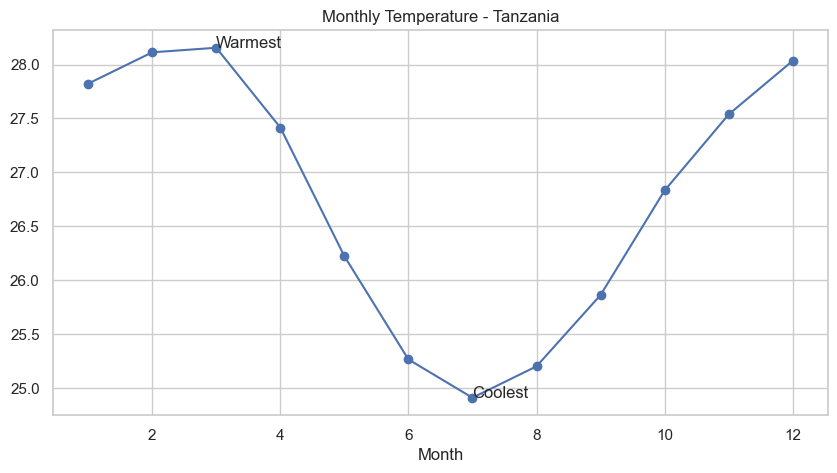

In [83]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.figure(figsize=(10,5))
monthly_temp.plot(marker="o")

plt.annotate("Warmest", xy=(warmest, monthly_temp.max()))
plt.annotate("Coolest", xy=(coolest, monthly_temp.min()))

plt.title("Monthly Temperature - Tanzania")
plt.show()

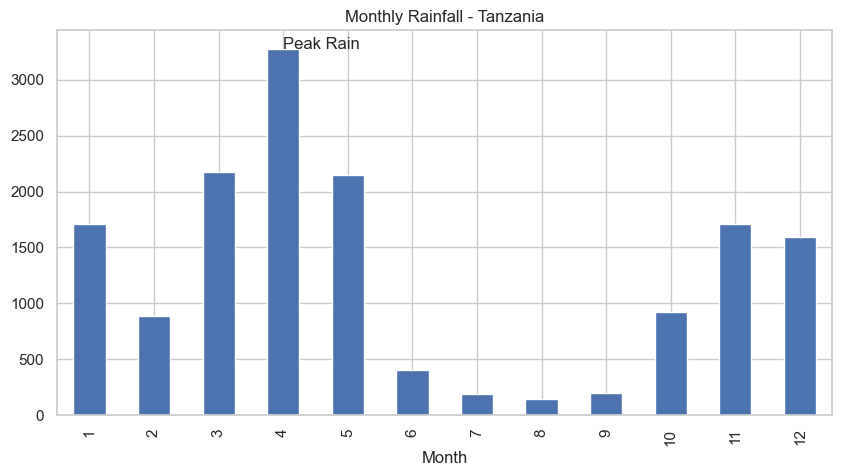

In [84]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

peak = monthly_rain.idxmax()

plt.figure(figsize=(10,5))
monthly_rain.plot(kind="bar")

plt.annotate("Peak Rain", xy=(peak-1, monthly_rain.max()))

plt.title("Monthly Rainfall - Tanzania")
plt.show()

### Time Series Analysis

- Temperature is stable throughout the year.
- Rainfall shows clear seasonal peaks.
- Tanzania exhibits tropical seasonal patterns.

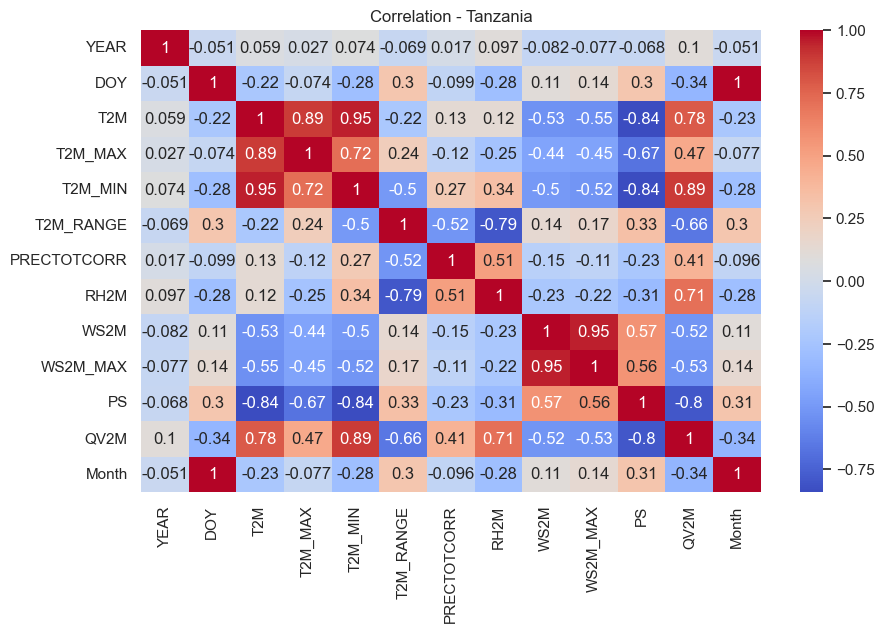

In [85]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation - Tanzania")
plt.show()

### Correlation Analysis

- Temperature variables are strongly correlated.
- Humidity and moisture are positively related.
- Temperature range negatively correlates with humidity.

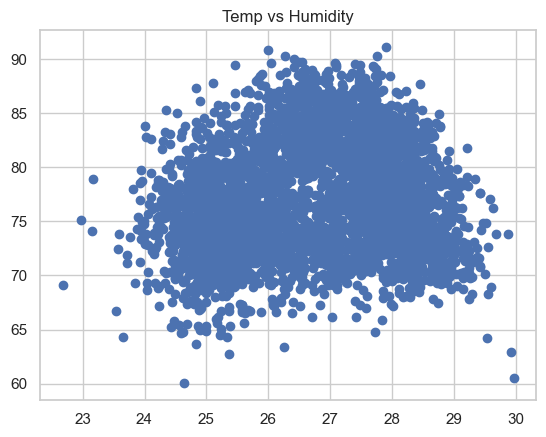

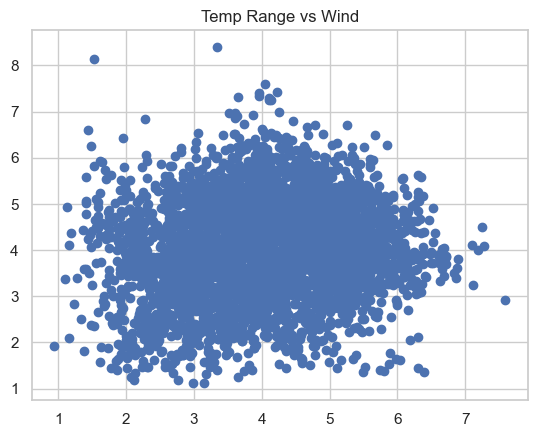

In [86]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temp vs Humidity")
plt.show()

plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.title("Temp Range vs Wind")
plt.show()

### Scatter Plot Analysis

- Temperature and humidity show moderate relationship.
- Wind speed has weak dependence on temperature range.

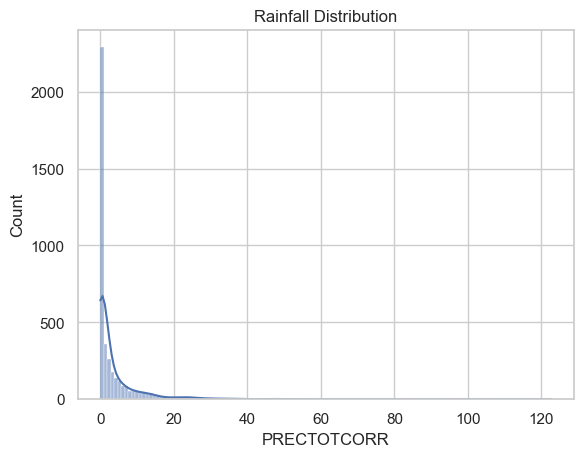

In [87]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.title("Rainfall Distribution")
plt.show()

### Rainfall Distribution

- Rainfall is right-skewed.
- Most days have low rainfall.
- Some days experience heavy rainfall.

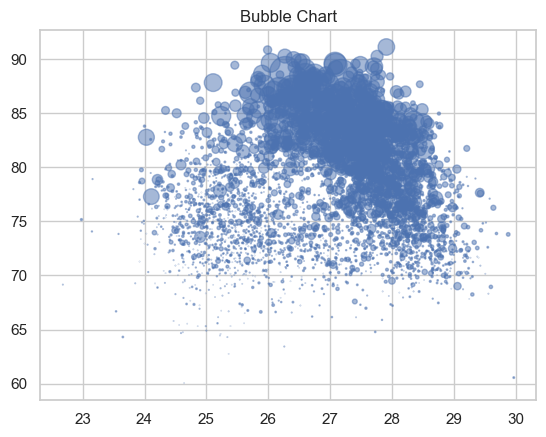

In [88]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*5, alpha=0.5)
plt.title("Bubble Chart")
plt.show()

### Bubble Chart Analysis

- Larger bubbles represent high rainfall events.
- Rainfall is associated with higher humidity.
- Temperature plays a secondary role.

In [89]:
df.to_csv("../data/tanzania_clean.csv", index=False)